In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [12]:
# xsec
file_xsec = "/home/zhe2/data/PACE/xSec_fit_output/interim_20250927T123954_retrieval_full_parallel.nc"
ds_xsec   = xr.open_dataset(file_xsec)
# svd
file_svd = "/home/zhe2/data/PACE/svd_retrieval_output/interim_20250701T002124_svd_retrieval_full_parallel.nc"
ds_svd   = xr.open_dataset(file_svd)
# L2AOP - nflh
l2aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/PACE_OCI.20250701T002124.L2.OC_AOP.V3_1.nc"
dtr_l2aop = xr.open_datatree(l2aop)
ds_l2aop = xr.merge(dtr_l2aop.to_dict().values())


/tmp/ipykernel_3622869/3118178147.py:9: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dtr_l2aop = xr.open_datatree(l2aop)


In [13]:
# nflh
nflh = ds_l2aop['nflh'].values
lat  = ds_l2aop['latitude'].values
lon  = ds_l2aop['longitude'].values

# sif_svd
sif_678_svd = ds_svd['sif_radiance_678nm'].values
lat_sif_svd = ds_svd['latitude'].values
lon_sif_svd = ds_svd['longitude'].values

# sif_xsec
sif_678_xsec = ds_xsec['sif_radiance_678nm'].values
lat_sif_xsec = ds_xsec['latitude'].values
lon_sif_xsec = ds_xsec['longitude'].values


NameError: name 'lon_sif' is not defined

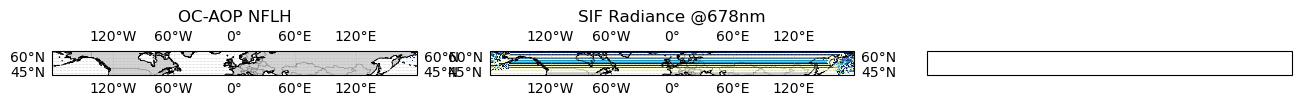

In [14]:
# Plot nflh and SIF radiance with common Cartopy map, adapted from overlapping_tropomi.ipynb (9-32)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

extent = [
    np.nanmin(lon), np.nanmax(lon),
    np.nanmin(lat), np.nanmax(lat)
]

vmin = 0.01
vmax = 1.0

# ---- NFLH panel ----
ax = axes[0]
ax.set_extent(extent, crs=ccrs.PlateCarree())
mesh_nflh = ax.pcolormesh(lon, lat, nflh, transform=ccrs.PlateCarree(),
                          cmap="YlGnBu_r", vmin=vmin, vmax=vmax)
ax.set_title("OC-AOP NFLH")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# ---- SIF radiance panel ----
ax = axes[1]
ax.set_extent(extent, crs=ccrs.PlateCarree())
mesh_sif = ax.pcolormesh(lon_sif_svd, lat_sif_svd, sif_678_svd, transform=ccrs.PlateCarree(),
                         cmap="YlGnBu_r", vmin=vmin, vmax=vmax)
ax.set_title("SIF Radiance @678nm")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# ---- SIF xsec panel ----
ax = axes[2]
ax.set_extent(extent, crs=ccrs.PlateCarree())
mesh_sif = ax.pcolormesh(lon_sif, lat_sif, sif_678, transform=ccrs.PlateCarree(),
                         cmap="YlGnBu_r", vmin=vmin, vmax=vmax)
ax.set_title("SIF xsec @678nm")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

plt.tight_layout()

# Optionally, add colorbars for each panel
cbar1 = fig.colorbar(mesh_nflh, ax=axes[0], orientation='vertical', shrink=0.8, label='NFLH')
cbar2 = fig.colorbar(mesh_sif, ax=axes[1], orientation='vertical', shrink=0.8, label='SIF Radiance (678 nm)')
cbar3 = fig.colorbar(mesh_sif, ax=axes[2], orientation='vertical', shrink=0.8, label='SIF xsec (678 nm)')

/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/matplotlib/axes/_axes.py:5297: RuntimeWarning: invalid value encountered in cast
  iy1 = np.round(iy).astype(int)
/home/zhe2/anaconda3/envs/ocean/lib/python3.14/site-packages/matplotlib/axes/_axes.py:5299: RuntimeWarning: invalid value encountered in cast
  iy2 = np.floor(iy).astype(int)


ValueError: operands could not be broadcast together with shapes (356211,) (2173848,) 

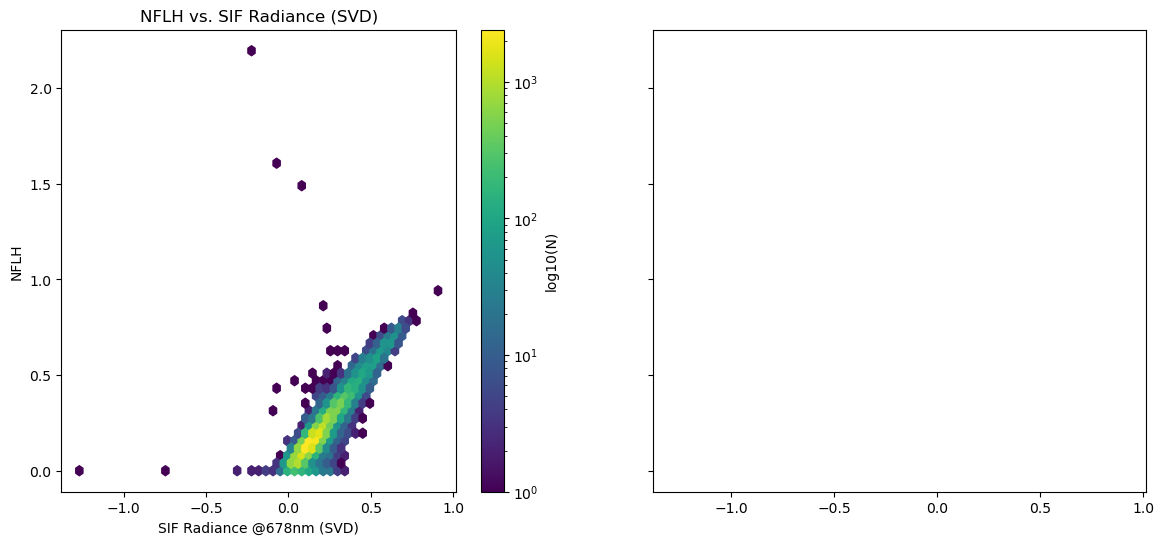

In [15]:
# Side-by-side scatterplots: nflh vs. sif_678_svd and nflh vs. sif_678 (xsec)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# First plot: nflh vs. sif_678_svd
x1 = sif_678_svd.flatten()
y1 = nflh.flatten()
hb1 = axes[0].hexbin(x1, y1, gridsize=50, cmap='viridis', bins='log')
axes[0].set_xlabel('SIF Radiance @678nm (SVD)')
axes[0].set_ylabel('NFLH')
axes[0].set_title('NFLH vs. SIF Radiance (SVD)')
cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label('log10(N)')

# Second plot: nflh vs. sif_678 (from xsec)
x2 = sif_678_xsec.flatten()
y2 = nflh.flatten()
axes[1].plot([x2.min(), x2.max()], [x2.min(), x2.max()], 'k--', label='1:1 line', zorder=10)
hb2 = axes[1].hexbin(x2, y2, gridsize=50, cmap='viridis', bins='log')
axes[1].set_xlabel('SIF xsec @678nm')
axes[1].set_ylabel('NFLH')
axes[1].set_title('NFLH vs. SIF xsec (678nm)')
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label('log10(N)')

plt.tight_layout()
plt.show()


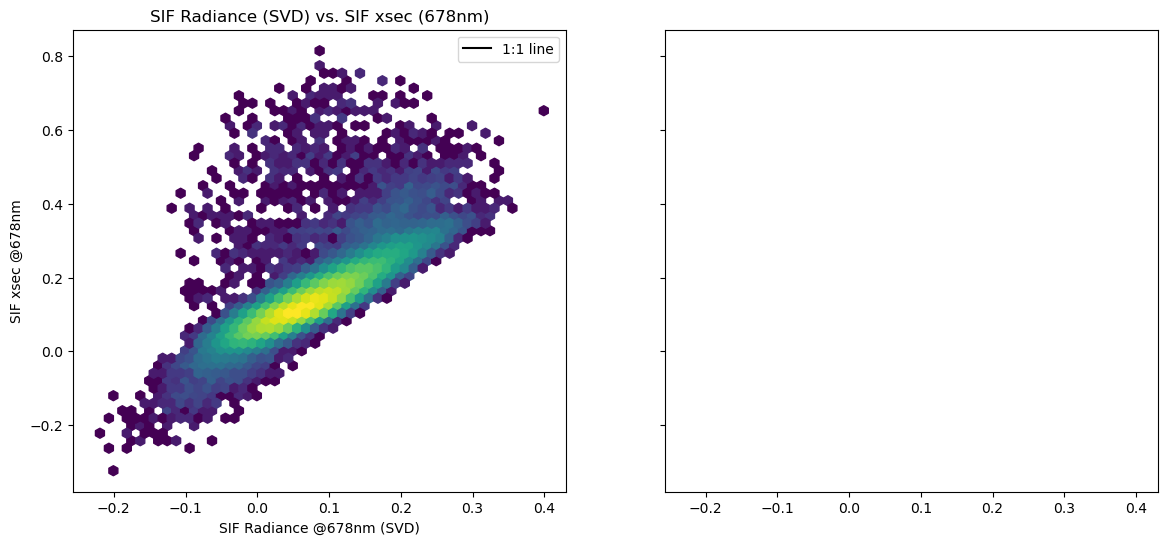

In [61]:
# svd vs. xsec
x1 = sif_678_svd.flatten()
x2 = sif_678_xsec.flatten()
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# First plot: sif_678_svd vs. sif_678_xsec
axes[0].hexbin(x1, x2, gridsize=50, cmap='viridis', bins='log')
axes[0].set_xlabel('SIF Radiance @678nm (SVD)')
axes[0].set_ylabel('SIF xsec @678nm')
axes[0].set_title('SIF Radiance (SVD) vs. SIF xsec (678nm)')

# To make sure the 1:1 line displays, it must span the same range on both axes
min_val = min(x1.min(), x2.min())
max_val = max(x1.max(), x2.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k-', label='1:1 line', zorder=10)

# Optionally, you can also bring the line to the front and add a legend to ensure it's visible:
axes[0].legend()